In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_excel("../dataset/online_retail.csv.xlsx")


In [4]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


In [6]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [7]:
df.describe()

,Quantity,InvoiceDate,UnitPrice,CustomerID
count,541909.000000,541909,541909.000000,406829.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114,15287.690570
min,-80995.000000,2010-12-01 08:26:00,-11062.060000,12346.000000
25%,1.000000,2011-03-28 11:34:00,1.250000,13953.000000
50%,3.000000,2011-07-19 17:17:00,2.080000,15152.000000
75%,10.000000,2011-10-19 11:27:00,4.130000,16791.000000
max,80995.000000,2011-12-09 12:50:00,38970.000000,18287.000000
std,218.081158,NaN,96.759853,1713.600303


In [8]:
df = df.dropna(subset=['CustomerID'])

In [9]:
df = df.drop_duplicates()

In [10]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [11]:
df['Revenue'] = df['Quantity'] * df['UnitPrice']

In [12]:
df[['Quantity','UnitPrice','Revenue']].head()

,Quantity,UnitPrice,Revenue
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [13]:
df.to_csv("../dataset/cleaned_ecommerce_data.csv", index=False)

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../dataset/cleaned_ecommerce_data.csv")
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

In [15]:
print(df.shape)
print(df.columns)

(401604, 9)
Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country', 'Revenue'],
      dtype='object')


In [16]:
df['MonthYear'] = df['InvoiceDate'].dt.to_period('M')

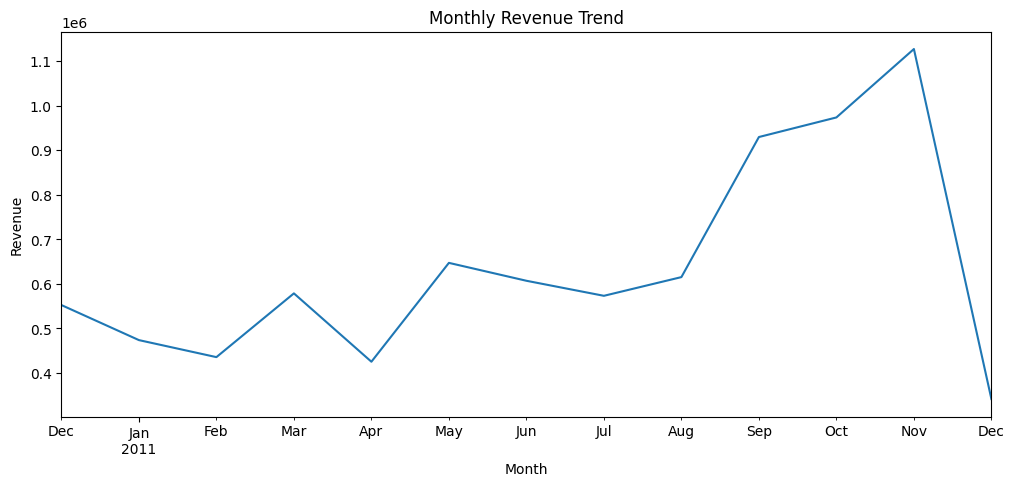

In [17]:
monthly_sales = df.groupby('MonthYear')['Revenue'].sum()

plt.figure(figsize=(12,5))
monthly_sales.plot()
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

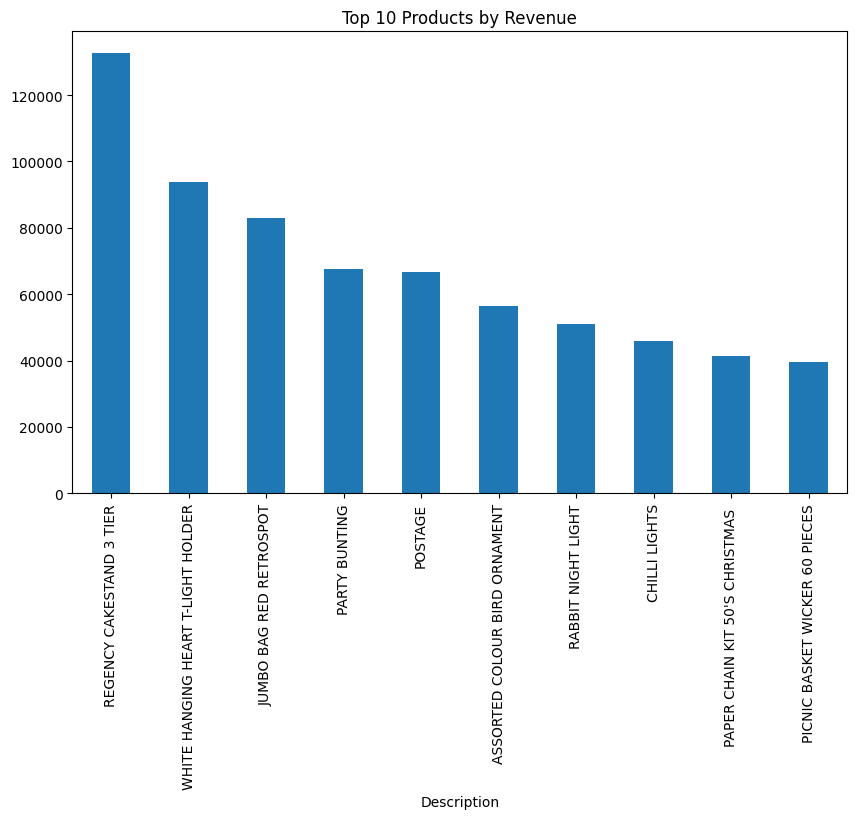

In [18]:
top_products = (
    df.groupby('Description')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))
top_products.plot(kind='bar')
plt.title("Top 10 Products by Revenue")
plt.show()

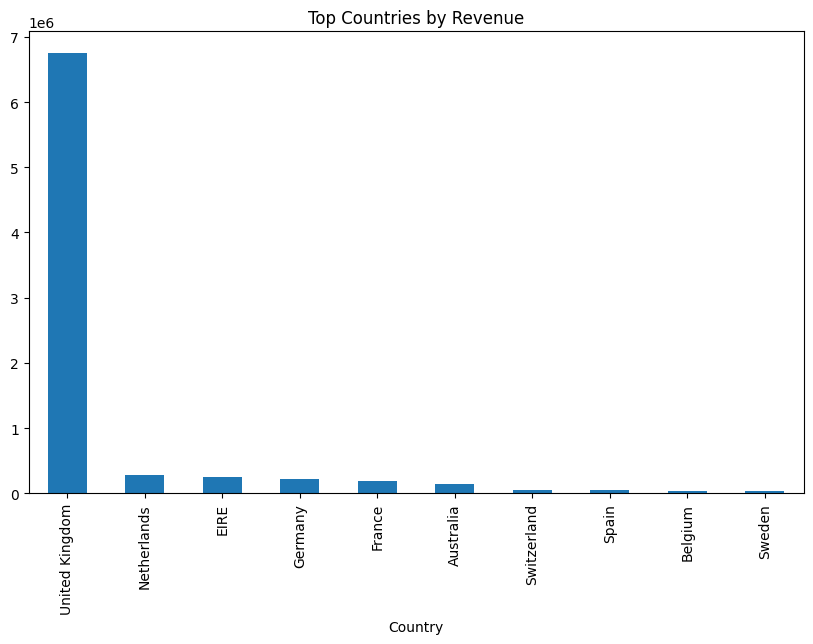

In [19]:
top_countries = (
    df.groupby('Country')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(10,6))
top_countries.plot(kind='bar')
plt.title("Top Countries by Revenue")
plt.show()

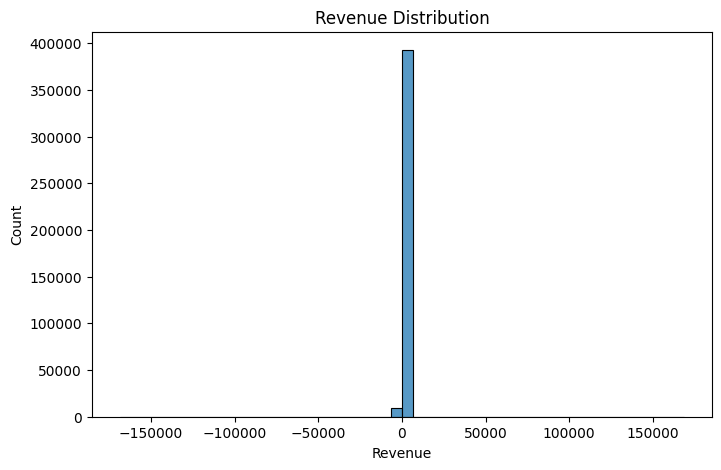

In [20]:
plt.figure(figsize=(8,5))
sns.histplot(df['Revenue'], bins=50)
plt.title("Revenue Distribution")
plt.show()

In [21]:
top_customers = (
    df.groupby('CustomerID')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print(top_customers)

CustomerID
14646.0    279489.02
18102.0    256438.49
17450.0    187322.17
14911.0    132458.73
12415.0    123725.45
14156.0    113214.59
17511.0     88125.38
16684.0     65892.08
13694.0     62690.54
15311.0     59284.19
Name: Revenue, dtype: float64


In [22]:
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)

rfm = df.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days,
    'InvoiceNo': 'count',
    'Revenue': 'sum'
})

rfm.columns = ['Recency','Frequency','Monetary']

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,2,0.00
12347.0,2,182,4310.00
12348.0,75,31,1797.24
12349.0,19,73,1757.55
12350.0,310,17,334.40


In [23]:
rfm['R'] = pd.qcut(rfm['Recency'],5,labels=[5,4,3,2,1])

rfm['F'] = pd.qcut(
    rfm['Frequency'].rank(method='first'),
    5,
    labels=[1,2,3,4,5]
)

rfm['M'] = pd.qcut(
    rfm['Monetary'],
    5,
    labels=[1,2,3,4,5]
)

rfm['RFM_Score'] = (
    rfm['R'].astype(str)
    + rfm['F'].astype(str)
    + rfm['M'].astype(str)
)

rfm.head()

,Recency,Frequency,Monetary,R,F,M,RFM_Score
CustomerID,,,,,,,
12346.0,326,2,0.00,1,1,1,111
12347.0,2,182,4310.00,5,5,5,555
12348.0,75,31,1797.24,2,3,4,234
12349.0,19,73,1757.55,4,4,4,444
12350.0,310,17,334.40,1,2,2,122


In [24]:
def segment(row):
    if row['RFM_Score'] == '555':
        return 'Champions'
    elif row['R'] >= 4 and row['F'] >= 4:
        return 'Loyal Customers'
    elif row['R'] >= 3 and row['F'] >= 3:
        return 'Potential Loyalists'
    elif row['R'] <= 2 and row['F'] >= 3:
        return 'At Risk'
    else:
        return 'Others'

rfm['Segment'] = rfm.apply(segment, axis=1)

In [25]:
print(rfm['Segment'].value_counts())

Segment
Others                 1749
Potential Loyalists     845
Loyal Customers         790
At Risk                 669
Champions               319
Name: count, dtype: int64


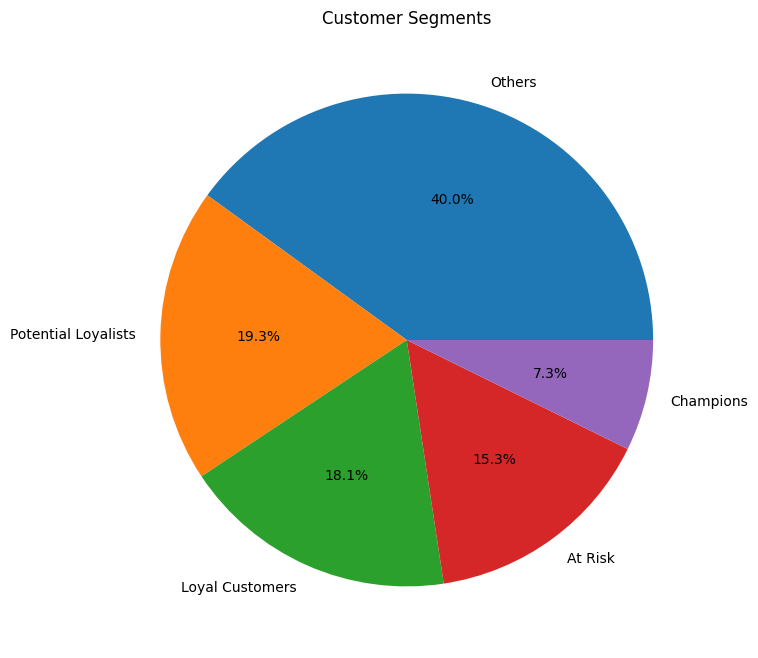

In [26]:
import matplotlib.pyplot as plt

rfm['Segment'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(8,8)
)

plt.title("Customer Segments")
plt.ylabel("")
plt.show()

In [27]:
rfm.to_csv("rfm_segments.csv")

In [28]:
from prophet import Prophet
print("Prophet Installed Successfully")

Prophet Installed Successfully


In [29]:
import pandas as pd

df = pd.read_csv("../dataset/cleaned_ecommerce_data.csv")

df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

monthly_sales = (
    df.groupby(pd.Grouper(key='InvoiceDate', freq='M'))
    ['Revenue']
    .sum()
    .reset_index()
)

monthly_sales.head()

C:\Users\Rahul\AppData\Local\Temp\ipykernel_11948\1769559711.py:8: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  df.groupby(pd.Grouper(key='InvoiceDate', freq='M'))


,InvoiceDate,Revenue
0,2010-12-31,552372.860
1,2011-01-31,473731.900
2,2011-02-28,435534.070
3,2011-03-31,578576.210
4,2011-04-30,425222.671


In [30]:
monthly_sales.columns = ['ds', 'y']

monthly_sales.head()

,ds,y
0,2010-12-31,552372.860
1,2011-01-31,473731.900
2,2011-02-28,435534.070
3,2011-03-31,578576.210
4,2011-04-30,425222.671


In [31]:
from prophet import Prophet

model = Prophet()

model.fit(monthly_sales)

01:48:22 - cmdstanpy - INFO - Chain [1] start processing
01:48:23 - cmdstanpy - INFO - Chain [1] done processing


In [33]:
future = model.make_future_dataframe(
    periods=3,
    freq='ME'
)

In [34]:
forecast[['ds','yhat','yhat_lower','yhat_upper']].tail()

,ds,yhat,yhat_lower,yhat_upper
11,2011-11-30,787896.807762,523004.364723,1.043931e+06
12,2011-12-31,818539.673338,555448.718969,1.068179e+06
13,2012-01-31,849182.538913,613884.594032,1.088362e+06
14,2012-02-29,877848.445419,624191.818789,1.141301e+06
15,2012-03-31,908491.310994,667158.584235,1.173600e+06


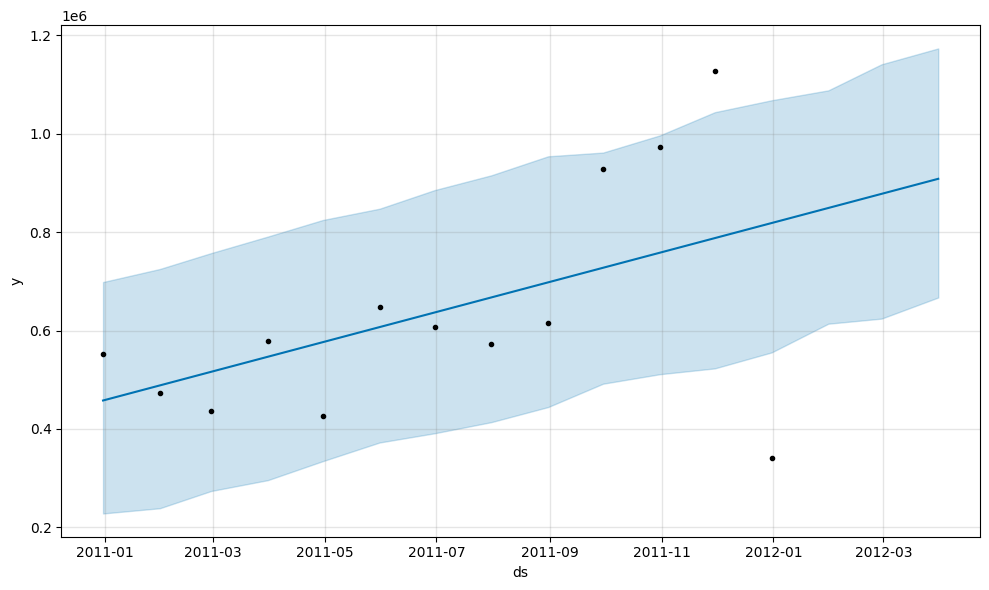

In [35]:
fig = model.plot(forecast)

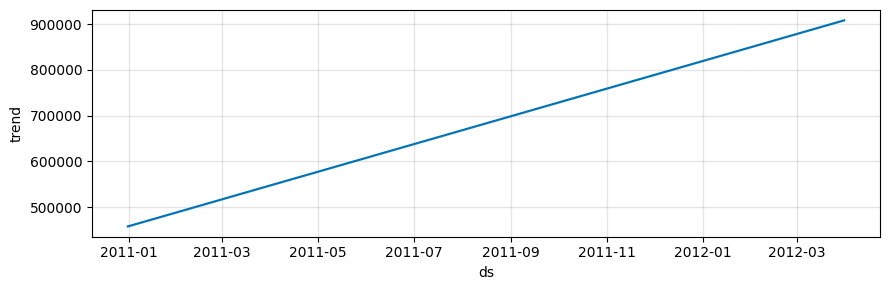

In [36]:
fig2 = model.plot_components(forecast)

In [37]:
forecast[['ds','yhat']].to_csv(
    "sales_forecast.csv",
    index=False
)